In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Use STIX fonts for math symbols
plt.rcParams['text.usetex'] = True # enable LaTeX rendering

# Plot time history of Nu and Sh over time

Data loaded successfully.
Background plotted successfully.
Updating frame 0, index 0
Updating frame 0, index 0
Updating frame 1, index 100
Updating frame 2, index 200
Updating frame 3, index 300
Updating frame 4, index 400
Updating frame 5, index 500
Updating frame 6, index 600
Updating frame 7, index 700
Updating frame 8, index 800
Updating frame 9, index 900
Updating frame 10, index 1000
Updating frame 11, index 1100
Updating frame 12, index 1200
Updating frame 13, index 1300
Updating frame 14, index 1400
Updating frame 15, index 1500
Updating frame 16, index 1600
Updating frame 17, index 1700
Updating frame 18, index 1800
Updating frame 19, index 1900
Updating frame 20, index 2000
Updating frame 21, index 2100
Updating frame 22, index 2200
Updating frame 23, index 2300
Updating frame 24, index 2400
Updating frame 25, index 2500
Updating frame 26, index 2600
Updating frame 27, index 2700
Updating frame 28, index 2800
Updating frame 29, index 2900
Updating frame 30, index 3000
Updatin

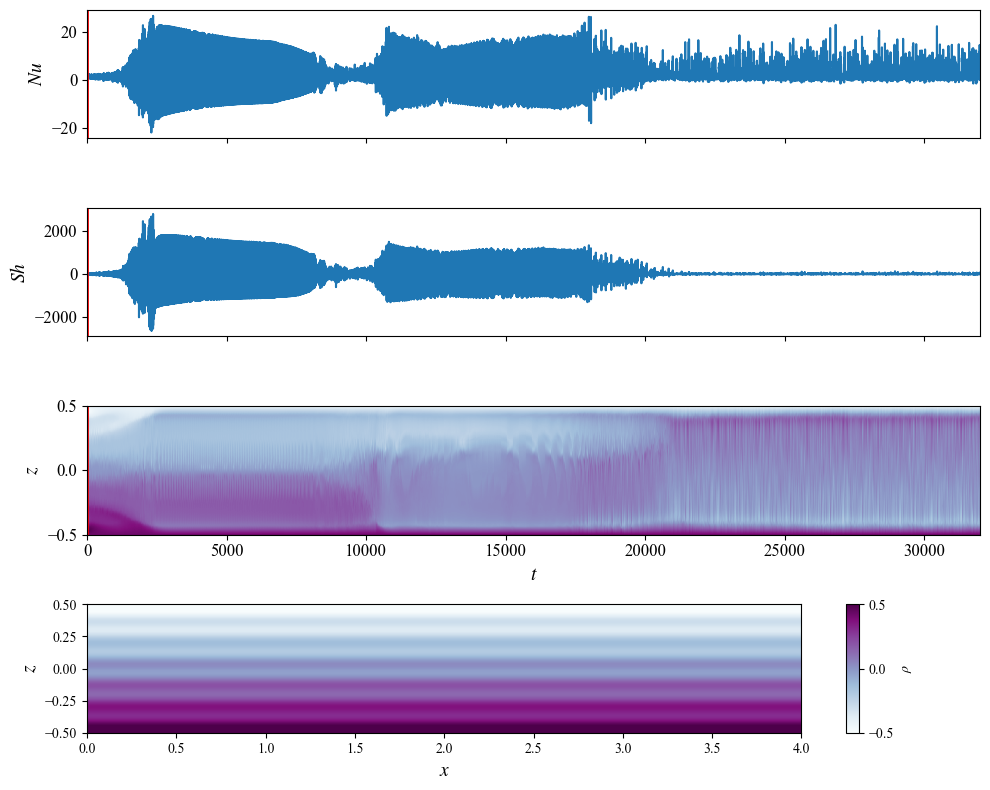

In [2]:
from func import *
from matplotlib.animation import FuncAnimation

start=0
end = 32000

# load data of Nu and Sh
[time,Nu]=readdata("Data/DNS/case3_kz6_nx768/energy.asc",17)
[_,Sh]=readdata("Data/DNS/case3_kz6_nx768/energy.asc",22)
time = time[start:end]  # downsample time for animation
Nu = Nu[start:end]
Sh = Sh[start:end]
# load density profiles
data = np.load("Data/DNS/case3_kz6_nx768/meandata.npz")
z = data["z"]
Density = data["dens"][start:end]
# print(np.shape(Density))
# print(np.shape(time))
print("Data loaded successfully.")

from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(4, 1, figure=fig)

ax1 = fig.add_subplot(gs[0,0])  # row 0, Nu
ax2 = fig.add_subplot(gs[1,0])  # row 1, Sh
ax3 = fig.add_subplot(gs[2,0])  # row 2, Horizontally-averaged density
ax4 = fig.add_subplot(gs[3,0])  # row 3, Density video

# --- Plot 1: Nu vs t ---
ax1.plot(time, Nu, '-',rasterized=True)
# ax1.set_xlabel(r'$t$', fontsize=14)
ax1.set_ylabel(r'$Nu$', fontsize=14)
ax1.set_xlim([0,32000])
ax1.set_xticklabels([], fontsize=14)
ax1.tick_params(axis='both', labelsize=12)
p1 = ax1.axvline(x=0, linestyle='-', linewidth=2, color='red')

# --- Plot 2: Sh vs t ---
ax2.plot(time, Sh, '-',rasterized=True)
# ax2.set_xlabel(r'$t$', fontsize=14)
ax2.set_ylabel(r'$Sh$', fontsize=14)
ax2.set_xlim([0,32000])
ax2.set_xticklabels([], fontsize=14)
ax2.tick_params(axis='both', labelsize=12)
p2 = ax2.axvline(x=0, linestyle='-', linewidth=2, color='red')

# --- Plot 3: density ---
X, Z = np.meshgrid(time, z)
ax3.pcolormesh(X,Z,Density.T, cmap='BuPu',shading='auto',rasterized=True,linewidth=0,antialiased=False)
ax3.set_xlabel(r'$t$',fontsize=14)
ax3.set_ylabel(r'$z$',fontsize=14)
ax3.set_xlim([0,32000])
ax3.tick_params(axis='both', labelsize=12)
p3 = ax3.axvline(x=0, linestyle='-', linewidth=2, color='red')

# --- Plot 4: density video ---
[zcoord,xcoord,temp] = z_averaged_scalar('2D/DNS/case3_yangpaper_Pr10_Ra1e6_Ri1/flowfields/t300.nc',1)
[zcoord,xcoord,salt] = z_averaged_scalar('2D/DNS/case3_yangpaper_Pr10_Ra1e6_Ri1/flowfields/s300.nc',1)
temp = temp-zcoord
salt = salt-zcoord
Lambda = 2
rho = (Lambda*salt-temp)/(Lambda-1)
X_ax4, Z_ax4 = np.meshgrid(xcoord, zcoord)
p4 = ax4.pcolormesh(X_ax4,Z_ax4,rho.T, shading='auto',vmin=-0.5,vmax=0.5, cmap='BuPu')
ax4.set_xlabel(r'$x$', fontsize=14)
ax4.set_ylabel(r'$z$', fontsize=14)
ax4.set_xlim(0, 4)
ax4.set_ylim(-0.5, 0.5)
plt.colorbar(p4, ax=ax4, ticks=[-0.5, 0, 0.5], shrink=1.0, aspect=10, label=r'$\rho$')

plt.tight_layout()

print("Background plotted successfully.")

# --- Update function ---
def update(frame):
    step = 100
    index = step * frame
    print(f"Updating frame {frame}, index {index}")

    p1.set_xdata([time[index], time[index]])
    p2.set_xdata([time[index], time[index]])
    p3.set_xdata([time[index], time[index]])

    [_,_,temp] = z_averaged_scalar(f'2D/DNS/case3_yangpaper_Pr10_Ra1e6_Ri1/flowfields/t{index}.nc',1)
    [_,_,salt] = z_averaged_scalar(f'2D/DNS/case3_yangpaper_Pr10_Ra1e6_Ri1/flowfields/s{index}.nc',1)
    temp = temp - zcoord
    salt = salt - zcoord
    rho = (Lambda*salt-temp)/(Lambda-1)
    p4.set_array(rho.T)
    return p1, p2, p3, p4

nframes = 320 # number of frames in the animation

# --- Create animation ---
ani = FuncAnimation(fig, update, frames=nframes, interval=40, blit=False, repeat=True)
# ani.save('Supplementary_movie_1_for_figure02.gif', writer='pillow', fps=30, dpi=300)
ani.save('Supplementary_movie_1.mp4', writer='ffmpeg', fps=30, dpi=120, bitrate=2000)